In [1]:
import os
from pathlib import Path
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
from rich.console import Console
from rich.table import Table

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "tdmd").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from examples.temporal_graphs import SNAP_TEMPORAL_GRAPH_URL, display_graph_snapshot, load_temporal_graph, reconstruct_tdmdii, relative_error

plt.style.use("ggplot")

In [2]:
data_path = PROJECT_ROOT / "examples" / "data" / "email-Eu-core-temporal-Dept3.txt.gz"
graph = load_temporal_graph(data_path, num_bins=32)
snapshots = graph.snapshots
snapshot_idx = 10

def draw_snapshot(ax, matrix, title, cmap="magma"):
    image = ax.imshow(display_graph_snapshot(matrix), origin="lower", cmap=cmap, aspect="auto")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return image

In [3]:
gamma = 0.999
result = reconstruct_tdmdii(snapshots, gamma=gamma)

states = snapshots.transpose(0, 2, 1).reshape(result.reconstructed_states.shape, order="F")
snapshot_true = snapshots[:, snapshot_idx, :]
snapshot_pred = result.reconstructed_tensor[:, snapshot_idx, :]
snapshot_re = relative_error(states[:, snapshot_idx], result.reconstructed_states[:, snapshot_idx])

table = Table(title="SNAP Temporal Graph TDMDII")
table.add_column("Name", no_wrap=True)
table.add_column("Value")
table.add_row("snapshot tensor shape", f"{tuple(snapshots.shape)}")
table.add_row("k_max", f"{int(result.multirank.max())}")
table.add_row("sum k_j", f"{int(result.multirank.sum())}")
table.add_row("mean state-wise RE", f"{result.state_errors.mean():.4e}")
table.add_row("snapshot RE", f"{snapshot_re:.4e}")
Console().print(table)

       SNAP Temporal Graph TDMDII       
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Name                  ┃ Value        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ snapshot tensor shape │ (89, 32, 89) │
│ k_max                 │ 31           │
│ sum k_j               │ 2652         │
│ mean state-wise RE    │ 4.2948e-01   │
│ snapshot RE           │ 2.8543e-01   │
└───────────────────────┴──────────────┘

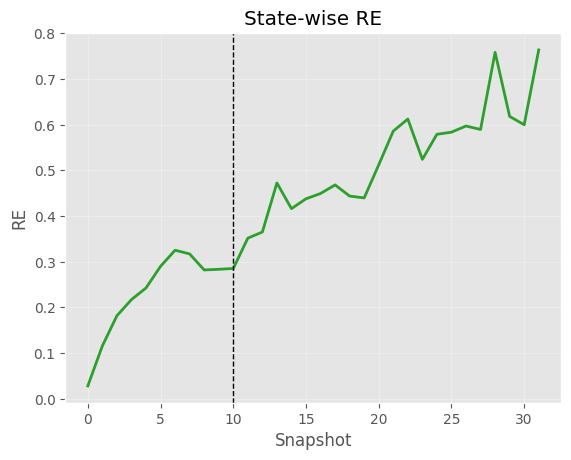

In [4]:
fig, ax = plt.subplots()

ax.plot(result.state_errors, linewidth=2, color="tab:green")
ax.axvline(snapshot_idx, color="black", linestyle="--", linewidth=1)
ax.set_title("State-wise RE")
ax.set_xlabel("Snapshot")
ax.set_ylabel("RE")
ax.grid(True, alpha=0.3)

plt.show();